# 분만취약지 지원 배분 진단과 우선순위 모형 — 통합 최종본

**프로젝트 주제** 

① 현행 분만취약지 지원 배분은 무엇으로 설명되는가(진단)

② 정부 지침의 정량 요건만으로 우선순위·사업유형을 배정하면 현행과 어디가 어긋나는가(처방)

③ 분만실 접근성만으로 설명되지 않는 이용률 공백은 무엇으로 설명되며, 분만실 지원은 어떻게 정밀화해야 하는가(확장)


## 0. 환경 설정

In [1]:
import os, warnings
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib, matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
from scipy.stats import fisher_exact, mannwhitneyu, spearmanr, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
warnings.filterwarnings('ignore')

# 한글 폰트: 환경에 존재하는 것 자동 선택
for p in ['/tmp/kr.ttf', 'C:/Windows/Fonts/malgun.ttf', '/System/Library/Fonts/AppleSDGothicNeo.ttc']:
    if os.path.exists(p):
        try: fm.fontManager.addfont(p)
        except Exception: pass
for f in ['Noto Sans KR','Malgun Gothic','AppleGothic','NanumGothic','Noto Sans CJK KR','Noto Sans CJK JP']:
    if any(x.name == f for x in fm.fontManager.ttflist):
        matplotlib.rcParams['font.family'] = f; break
matplotlib.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 200)

# 데이터 경로 자동 탐지 (같은 폴더 또는 uploads)
UP = next(p for p in [Path('../02_데이터/헬스맵_원본'), Path('02_데이터/헬스맵_원본'), Path('.'), Path('/mnt/user-data/uploads'), Path('/home/claude'), Path('/home/claude/hm2')]
          if (p/'의료취약지.csv').exists())
OD_DIR = next(p for p in [UP, Path('../02_데이터/헬스맵_원본'), Path('/home/claude/hm2'), Path('.')]
              if (p/'유출입_진료시설.csv').exists())
print('데이터 경로:', UP.resolve(), '| OD:', OD_DIR.resolve())

def rd(fname, base=None, **kw):
    base = base or UP
    for enc in ['utf-8-sig', 'cp949']:
        try: return pd.read_csv(base/fname, encoding=enc, **kw)
        except UnicodeDecodeError: continue
    raise ValueError(fname)

데이터 경로: /home/claude/repo/02_데이터/헬스맵_원본 | OD: /home/claude/repo/02_데이터/헬스맵_원본


## 1. 종속변수 구축 — 공고문 108개 시·군 전사

보건복지부 공고 제2026-144호 5-①의 등급표를 (시도, 시군구, 등급, 기지원`*`)로 전사한다.
동명 시군구(강원 고성군 / 경남 고성군)가 있으므로 키는 반드시 **(시도, 시군구) 복합키**다.
전사 정확성은 공고문 각주의 개수(A 32 / B 21 / C 55, `*` 합계는 지침 3.3의 57개소)와 대조해 검증한다.

In [2]:
S = {'인천':'인천광역시','경기':'경기도','강원':'강원도','충북':'충청북도','충남':'충청남도',
     '전북':'전라북도','전남':'전라남도','대구':'대구광역시','경북':'경상북도','경남':'경상남도',
     '제주':'제주특별자치도'}
A_ALL=[('인천','옹진군'),('인천','강화군'),('대구','군위군'),('경기','연천군'),('경기','가평군'),('경기','양평군'),
('강원','인제군'),('강원','정선군'),('강원','평창군'),('강원','홍천군'),('강원','화천군'),
('충북','괴산군'),('충북','단양군'),('충북','보은군'),
('전북','장수군'),('전북','진안군'),('전북','무주군'),
('전남','보성군'),('전남','신안군'),('전남','완도군'),('전남','진도군'),
('경북','영덕군'),('경북','영양군'),('경북','의성군'),('경북','울릉군'),('경북','청도군'),('경북','청송군'),('경북','봉화군'),
('경남','의령군'),('경남','남해군'),('경남','합천군'),('경남','산청군')]
A_STAR={'옹진군','인제군','정선군','화천군','괴산군','단양군','보은군','진안군','보성군','완도군',
        '진도군','영양군','의성군','울릉군','봉화군','합천군','산청군'}
B_ALL=[('강원','횡성군'),('강원','고성군'),('강원','양양군'),('충북','진천군'),('충북','음성군'),
('충남','금산군'),('충남','부여군'),('충남','청양군'),('충남','예산군'),('충남','태안군'),
('전북','임실군'),('전북','순창군'),('전북','부안군'),
('전남','곡성군'),('전남','장흥군'),('전남','함평군'),('전남','구례군'),
('경북','문경시'),('경북','성주군'),('경남','고성군'),('경남','함양군')]
B_STAR={'부여군','함평군','문경시','함양군'}
C_ALL=[('경기','포천시'),('경기','여주시'),
('강원','강릉시'),('강원','태백시'),('강원','속초시'),('강원','삼척시'),('강원','영월군'),('강원','철원군'),('강원','양구군'),
('충북','충주시'),('충북','제천시'),('충북','옥천군'),('충북','영동군'),('충북','증평군'),
('충남','공주시'),('충남','보령시'),('충남','서산시'),('충남','논산시'),('충남','계룡시'),('충남','당진시'),('충남','서천군'),('충남','홍성군'),
('전북','정읍시'),('전북','남원시'),('전북','김제시'),('전북','완주군'),('전북','고창군'),
('전남','나주시'),('전남','광양시'),('전남','담양군'),('전남','고흥군'),('전남','화순군'),('전남','강진군'),('전남','해남군'),
('전남','영암군'),('전남','무안군'),('전남','영광군'),('전남','장성군'),
('경북','김천시'),('경북','안동시'),('경북','영주시'),('경북','영천시'),('경북','상주시'),('경북','고령군'),('경북','칠곡군'),('경북','예천군'),('경북','울진군'),
('경남','통영시'),('경남','사천시'),('경남','밀양시'),('경남','함안군'),('경남','창녕군'),('경남','하동군'),('경남','거창군'),
('제주','서귀포시')]
C_STAR={'포천시','태백시','속초시','삼척시','영월군','철원군','양구군','충주시','제천시','영동군',
'공주시','보령시','논산시','홍성군','정읍시','남원시','김제시','고창군','광양시','고흥군','강진군',
'해남군','영광군','김천시','안동시','영주시','영천시','상주시','예천군','울진군','통영시','사천시',
'밀양시','하동군','거창군','서귀포시'}

rows=[]
for lst,g,st in [(A_ALL,'A',A_STAR),(B_ALL,'B',B_STAR),(C_ALL,'C',C_STAR)]:
    for s,n in lst:
        rows.append((S[s], n, g, int(n in st)))
base = pd.DataFrame(rows, columns=['시도명','시군구명','등급','지원여부'])

# 전사 검증 — 공고문 각주·지침 3.3과 대조
cnt = base['등급'].value_counts()
assert (cnt['A'],cnt['B'],cnt['C'])==(32,21,55), cnt
assert base['지원여부'].sum()==57, base['지원여부'].sum()
assert base.duplicated(['시도명','시군구명']).sum()==0
print('전사 검증 통과: A 32 / B 21 / C 55 = 108곳, 기지원 * = 57곳')
print(base.groupby('등급')['지원여부'].agg(['sum','count','mean']).rename(columns={'mean':'지원율'})
      .assign(지원율=lambda d:(d['지원율']*100).round(1)).to_string())

전사 검증 통과: A 32 / B 21 / C 55 = 108곳, 기지원 * = 57곳
    sum  count   지원율
등급                  
A    17     32  53.1
B     4     21  19.0
C    36     55  65.5


### 1-1. C등급의 순환 구조 — 주 분석에서 제외하는 이유

공고문 각주: **"(C등급) 가임 배경인구수 부족 or 분만취약지 사업 旣 지원"**.
지원을 받으면 C로 분류되므로 C의 지원율 65.5%는 취약도의 결과가 아니라 **정의의 결과**다.
따라서 ① 현행 배분과의 대조 통계, ② 배분 결정요인 회귀는 모두 **A·B 53곳**에서 수행하고,
C를 포함한 108곳 순위는 부록으로만 제시한다.

## 2. 사용 데이터

| 소스 | 변수 | 성격 |
|---|---|---|
| 의료취약지.csv | 접근성취약인구비율, TRI, 가임여성인구비, 분만건수(주민), 재정자립도, 인구수 | 필요도 + 역량 |
| 기관정보.csv | 병원급이상수, 공공의료기관수, 분만실보유기관수, 산부인과개설수 | 역량(수행 주체) |
| 유출입_진료시설.csv | 관내분만수행량(공급), 관내이용률, 관외유출률 | 행태 |

In [3]:
SIDO_FIX = {'강원특별자치도':'강원도','전북특별자치도':'전라북도'}
def norm(sido, sgg):
    sido = SIDO_FIX.get(sido, sido)
    if sgg=='군위군': sido='경상북도'   # 2023.7 대구 편입 이전 기준으로 통일
    return sido
KEY=['시도명','시군구명']
base['시도명']=[norm(s,g) for s,g in zip(base['시도명'],base['시군구명'])]

mv = rd('의료취약지.csv')
mv['시도명']=[norm(s,g) for s,g in zip(mv['시도명'],mv['시군구명'])]
df = base.merge(mv, on=KEY, how='left')
assert df['시군구코드'].notna().all(), '의료취약지 매칭 실패'
df = df.rename(columns={'분만_접근성취약인구비율(백분율)':'접근성취약인구비율','분만_TRI(백분율)':'TRI',
    '가임여성인구(백분율)':'가임여성인구비','재정자립도(백분율)':'재정자립도',
    '인구수(명)':'인구수','분만건수(건)':'분만건수'})
df['지역']=df['시도명'].str[:2]+' '+df['시군구명']
print('의료취약지 결합:', df.shape)

의료취약지 결합: (108, 27)


In [4]:
ki = pd.read_csv(UP/'기관정보.csv', dtype=str, low_memory=False)
ki['시군구명']=ki['소재지'].map(lambda a:str(a).split()[1] if len(str(a).split())>1 else None)
ki['시도명']=[norm(s,g) for s,g in zip(ki['시도명'],ki['시군구명'])]
col = lambda key: next(c for c in ki.columns if key in c)
yes = lambda s:(s=='Y').sum()
agg = ki.groupby(KEY).agg(
    공공의료기관수=(col('공공의료기관'),yes),
    분만실보유기관수=(col('분만실'),yes),
    산부인과개설수=(col('산부인과'),yes)).reset_index()
hosp = ki[ki['요양종별'].isin(['상급종합병원','종합병원','병원'])]
agg = agg.merge(hosp.groupby(KEY).size().rename('병원급이상수').reset_index(), on=KEY, how='left')
agg['병원급이상수']=agg['병원급이상수'].fillna(0)
df = df.merge(agg, on=KEY, how='left')
for c in ['공공의료기관수','분만실보유기관수','산부인과개설수','병원급이상수']:
    df[c]=df[c].fillna(0)
print('기관정보 결합 완료 | 미매칭', df['산부인과개설수'].isna().sum(), '건')

기관정보 결합 완료 | 미매칭 0 건


In [5]:
fl = rd('유출입_진료시설.csv', base=OD_DIR)
fl = fl[fl['중분류']=='분만실']
supply = fl.groupby('지역1')['입원건수'].sum().rename('관내분만수행량')   # 지역1 = 의료기관 소재지(공급)
demand = fl.groupby('지역2')['입원건수'].sum().rename('주민분만총건수')   # 지역2 = 환자 거주지(수요)
stay   = fl[fl['지역1']==fl['지역2']].set_index('지역1')['입원건수'].rename('관내분만건수')
od = pd.concat([supply,demand,stay],axis=1).fillna(0)
od.index.name='시군구코드'; od=od.reset_index()
df['시군구코드']=df['시군구코드'].astype('Int64'); od['시군구코드']=od['시군구코드'].astype('Int64')
df = df.merge(od, on='시군구코드', how='left')
for c in ['관내분만수행량','주민분만총건수','관내분만건수']: df[c]=df[c].fillna(0)
df['관내이용률']=np.where(df['주민분만총건수']>0, df['관내분만건수']/df['주민분만총건수']*100, 0)
df['관외유출률']=100-df['관내이용률']

# ── 프록시 이중 검증 ──
r = df['분만건수'].corr(df['주민분만총건수'])
mae = (df['분만건수']-df['주민분만총건수']).abs().mean()
print(f'[검증1] 공식 분만건수 vs OD 재가공 주민분만: r={r:.6f}, MAE={mae:.2f}')
no_ob = df[df['산부인과개설수']==0]
print(f'[검증2] 산부인과 미개설 {len(no_ob)}곳의 관내분만수행량 합 = {int(no_ob["관내분만수행량"].sum())} (0이면 방향·프록시 정합)')

[검증1] 공식 분만건수 vs OD 재가공 주민분만: r=0.999988, MAE=0.26
[검증2] 산부인과 미개설 8곳의 관내분만수행량 합 = 0 (0이면 방향·프록시 정합)


## 3. 1단계 — 현행 배분 진단 (A·B 53곳)

지원여부   0   1
등급          
A     15  17
B     17   4 

A등급 지원율 53.1%  vs  B등급 19.0%
Fisher 정확검정 p=0.021 | A등급의 지원 오즈는 B등급의 4.82배


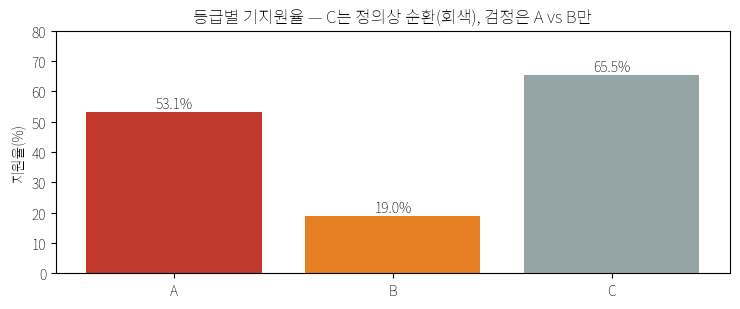

In [6]:
ab = df[df['등급'].isin(['A','B'])].copy().reset_index(drop=True)
tab = pd.crosstab(ab['등급'], ab['지원여부'])
_, p = fisher_exact(tab.values)
orAB = (tab.loc['A',1]/tab.loc['A',0]) / (tab.loc['B',1]/tab.loc['B',0])
print(tab.to_string(), '\n')
print(f'A등급 지원율 {tab.loc["A",1]/tab.loc["A"].sum()*100:.1f}%  vs  B등급 {tab.loc["B",1]/tab.loc["B"].sum()*100:.1f}%')
print(f'Fisher 정확검정 p={p:.3f} | A등급의 지원 오즈는 B등급의 {orAB:.2f}배')

fig,ax=plt.subplots(figsize=(7.5,3.2))
g = df.groupby('등급')['지원여부'].mean().mul(100)
bars=ax.bar(g.index, g.values, color=['#c0392b','#e67e22','#95a5a6'])
ax.bar_label(bars, fmt='%.1f%%'); ax.set_ylabel('지원율(%)'); ax.set_ylim(0,80)
ax.set_title('등급별 기지원율 — C는 정의상 순환(회색), 검정은 A vs B만')
plt.tight_layout(); plt.show()

### 통계 검정 수행

In [7]:
NEED=['접근성취약인구비율','TRI','가임여성인구비','관외유출률']
CAP =['재정자립도','병원급이상수','공공의료기관수']
rows=[]
for c in NEED+CAP:
    a,b = ab.loc[ab['지원여부']==0,c], ab.loc[ab['지원여부']==1,c]
    rows.append({'변수':c,'진영':'필요도' if c in NEED else '역량',
                 '미지원중앙값':round(a.median(),2),'기지원중앙값':round(b.median(),2),
                 'p_MW':mannwhitneyu(a,b).pvalue})
cmp = pd.DataFrame(rows)
cmp['p_BH'] = multipletests(cmp['p_MW'], method='fdr_bh')[1]
cmp[['p_MW','p_BH']]=cmp[['p_MW','p_BH']].round(3)
print(cmp.to_string(index=False))
print('\n→ BH 보정 후 유의(0.05)한 단변량 차이:', (cmp['p_BH']<.05).sum(), '개')

       변수  진영  미지원중앙값  기지원중앙값  p_MW  p_BH
접근성취약인구비율 필요도   29.43   75.09 0.006 0.043
      TRI 필요도   16.38    2.02 0.021 0.074
  가임여성인구비 필요도   12.50   11.32 0.129 0.180
    관외유출률 필요도  100.00  100.00 0.838 0.841
    재정자립도  역량    9.15    8.20 0.100 0.180
   병원급이상수  역량    1.00    1.00 0.841 0.841
  공공의료기관수  역량    0.00    0.00 0.109 0.180

→ BH 보정 후 유의(0.05)한 단변량 차이: 1 개


### 3-1. 로지스틱 회귀 — 배분은 필요도로 설명되는가, 역량으로 설명되는가

사건 21건이므로 EPV(events per variable) 10 기준 **주모형 변수는 2개**가 정석이다.
따라서 개별 p값 대신 **블록 우도비검정(LR test)** 을 판단 근거로 삼는다:
필요도 블록만 넣은 모형에 역량 블록을 추가했을 때 적합이 유의하게 좋아지는가(역·순 동일).
제출본의 5변수 모형은 EPV≈4로 과적합 위험이 있어 참고로만 유지한다.

In [8]:
Xf=['접근성취약인구비율','TRI','재정자립도','병원급이상수']
v=pd.DataFrame({'변수':Xf})
Xc=sm.add_constant(ab[Xf].astype(float))
v['VIF']=[variance_inflation_factor(Xc.values,i+1) for i in range(len(Xf))]
print(v.round(2).to_string(index=False),'\n')

def logit(cols,label):
    res=sm.Logit(ab['지원여부'], sm.add_constant(ab[cols].astype(float))).fit(disp=0)
    out=pd.DataFrame({'오즈비':np.exp(res.params),'p':res.pvalues}).round(3)
    print(f'── {label} | n={len(ab)}, 사건={int(ab["지원여부"].sum())}, McFadden R²={res.prsquared:.3f}')
    print(out.to_string(),'\n'); return res
m_need=logit(['접근성취약인구비율','TRI'],'필요도 블록 (주모형)')
m_cap =logit(['재정자립도','병원급이상수'],'역량 블록 (주모형)')
m_full=logit(Xf,'전체 4변수 (참고)')

lr_cap  = 2*(m_full.llf-m_need.llf); p_cap  = chi2.sf(lr_cap,2)
lr_need = 2*(m_full.llf-m_cap.llf);  p_need = chi2.sf(lr_need,2)
print(f'LR 검정 — 필요도 모형에 역량 블록 추가: χ²(2)={lr_cap:.2f}, p={p_cap:.3f}')
print(f'LR 검정 — 역량 모형에 필요도 블록 추가: χ²(2)={lr_need:.2f}, p={p_need:.3f}')

# 부트스트랩 계수 부호 안정성 (전체 모형)
rng=np.random.default_rng(42); signs=[]; fail=0
for _ in range(500):
    s=ab.sample(len(ab),replace=True,random_state=rng.integers(1e9))
    try:
        r=sm.Logit(s['지원여부'],sm.add_constant(s[Xf].astype(float))).fit(disp=0,maxiter=200)
        signs.append(np.sign(r.params[Xf]))
    except Exception: fail+=1
sg=pd.DataFrame(signs)
print('\n부트스트랩(500회) 계수 부호 일관성: ')
print(((sg>0).mean()*100).round(1).rename('양(+) 비율 %').to_string(), f'\n수렴 실패 {fail}회')

       변수  VIF
접근성취약인구비율 1.54
      TRI 1.45
    재정자립도 1.12
   병원급이상수 1.09 

── 필요도 블록 (주모형) | n=53, 사건=21, McFadden R²=0.118
             오즈비      p
const      0.262  0.107
접근성취약인구비율  1.021  0.048
TRI        0.985  0.606 

── 역량 블록 (주모형) | n=53, 사건=21, McFadden R²=0.081
          오즈비      p
const   6.333  0.139
재정자립도   0.784  0.064
병원급이상수  1.035  0.904 

── 전체 4변수 (참고) | n=53, 사건=21, McFadden R²=0.163
             오즈비      p
const      1.078  0.960
접근성취약인구비율  1.021  0.065
TRI        0.993  0.818
재정자립도      0.834  0.137
병원급이상수     1.216  0.532 

LR 검정 — 필요도 모형에 역량 블록 추가: χ²(2)=3.26, p=0.196
LR 검정 — 역량 모형에 필요도 블록 추가: χ²(2)=5.85, p=0.054



부트스트랩(500회) 계수 부호 일관성: 
접근성취약인구비율    93.2
TRI          42.2
재정자립도         4.2
병원급이상수       79.4 
수렴 실패 0회


### 3-2. 1단계 해석

**확정된 사실** — A 53.1% vs B 19.0%의 지원율 격차는 유의하다(Fisher p=0.021, OR=4.82).

**부분적으로만 조준되는 배분** — 접근성취약 비율은 지원과 양(+)의 연관을 보인다
(필요도 모형 오즈비 1.021/%p, p=0.048; 부트스트랩 부호 일관성 93%). 즉 등급 축(접근성)을
따라가는 경향 자체는 있다. 그러나 ① TRI 등 나머지 필요도 지표는 설명력이 없고(부호 일관성 42%),
② 역량 블록 추가는 적합을 유의하게 개선하지 못하며(χ²(2)=3.26, p=0.196),
③ 전체 모형 McFadden R²=0.16으로 배분의 대부분이 미설명으로 남는다.

**결론** — "역량이 지배한다"고 단정할 수도, "필요도대로 배분된다"고 할 수도 없다.
공개 지역지표로는 A·B 내부의 선정을 식별할 수 없으며, 심사 배점(정성 80점)·신청주의 구조가
시사하듯 배분 규칙은 데이터 바깥(신청 여부·계획서 품질·인력 수급 계획)에 있다.
→ 그렇다면 필요한 것은 **명시적 규칙**이다. 2단계에서 지침의 정량 요건만으로 이를 구성한다.

## 4. 2단계 — 우선순위·유형 배정 모형

**방법론적 전제: 새 기준을 만들지 않는다.** 지침·공고문에 이미 있는 정량 요건만 사용한다.

| 임계값 | 값 | 출처 |
|---|---|---|
| 최소 배경인구 | 36,588명 | 지침 C등급 정의 (인쇄 p.8) |
| 분만가능기관 | 연 분만 50건 이상 | 지침 3.1 (인쇄 p.6) |
| 접근성 취약 | 취약인구비율 ≥30% | 지침 3.1 |
| 이용률 취약 | TRI <30% | 지침 3.1 |

In [9]:
POP_MIN, BIRTH_MIN, ACC_CUT, TRI_CUT = 36588, 50, 30, 30

### 4-1. 우선순위 지표 — 심도(S)·부담(B) 이원 시나리오

역량 지표는 우선순위에 넣지 않는다(1단계 결론: 배분이 필요도를 온전히 따르지도, 관측 역량으로
설명되지도 않으므로, 규범적 기준선은 필요도만으로 세운다). 필요도에는 **두 가지 정당한 관점**이
있다.

| 시나리오 | 정의 | 관점 | 상위에 오는 지역 |
|---|---|---|---|
| **S(심도)** | 접근성취약 · 이용률결핍(100−TRI) · 관외유출률의 TOPSIS | 가장 심하게 고립된 곳 먼저 (worst-off) | 청송·영양형 — 비율 100%, 소인구 |
| **B(부담)** | **미충족분만 = 분만건수 × (1−TRI/100)** 내림차순 | 60분 밖 출산 **총량**이 큰 곳 먼저 | 양평·진천형 — 비율은 낮아도 절대 건수가 큼 |

두 관점을 하나의 합성점수로 섞지 않는 이유: 상충하는 가치를 평균하면 양쪽 모두에서 정당성을
잃는다. 두 순위를 나란히 제시하고 선택을 정책 판단에 넘기는 것이 정직하다.

In [10]:
ab['이용률결핍']=100-ab['TRI']
ab['미충족분만']=(ab['분만건수']*(1-ab['TRI']/100)).round(0)
X_S = ab[['접근성취약인구비율','이용률결핍','관외유출률']].rename(
      columns={'접근성취약인구비율':'접근성취약','관외유출률':'관외유출'}).astype(float)
chk = X_S.assign(미충족분만=ab['미충족분만']).corr().round(3)
print('심도 지표 ↔ 부담 지표 상관:'); print(chk.to_string())
print()
print('※ 미충족분만은 심도 3지표와 상관이 낮거나 음(-) — 별개의 축이며, 합성이 아닌 병렬 제시가 타당하다.')
print('※ 관외유출은 A·B 대부분이 100%라 분산이 작다(중앙값 100). 가중치 산출에서 자연히 낮은 비중을 받는다.')

심도 지표 ↔ 부담 지표 상관:
       접근성취약  이용률결핍   관외유출  미충족분만
접근성취약  1.000  0.540  0.153 -0.153
이용률결핍  0.540  1.000  0.124  0.030
관외유출   0.153  0.124  1.000 -0.471
미충족분만 -0.153  0.030 -0.471  1.000

※ 미충족분만은 심도 3지표와 상관이 낮거나 음(-) — 별개의 축이며, 합성이 아닌 병렬 제시가 타당하다.
※ 관외유출은 A·B 대부분이 100%라 분산이 작다(중앙값 100). 가중치 산출에서 자연히 낮은 비중을 받는다.


In [11]:
def minmax(M): return (M-M.min())/(M.max()-M.min())
def entropy_weight(M):
    Z=minmax(M)+1e-6; P=Z/Z.sum(); k=1/np.log(len(M))
    E=-(P*np.log(P)).sum()*k; d=1-E; return d/d.sum()
def critic_weight(M):
    Z=minmax(M); s=Z.std(ddof=1); Cj=s*(1-Z.corr()).sum(axis=0); return Cj/Cj.sum()
def topsis(M,w):
    V=M/np.sqrt((M**2).sum(axis=0)); V=V*w
    best,worst=V.max(),V.min()
    Dp=np.sqrt(((V-best)**2).sum(axis=1)); Dm=np.sqrt(((V-worst)**2).sum(axis=1))
    return Dm/(Dp+Dm)

eS = entropy_weight(X_S); cS = critic_weight(X_S); wS=(eS+cS)/2; wS=wS/wS.sum()
print('시나리오 S 가중치'); print(pd.DataFrame({'엔트로피':eS,'CRITIC':cS,'평균':wS}).round(3).to_string())

ab['점수S']=topsis(X_S,wS.values); ab['순위S']=ab['점수S'].rank(ascending=False,method='min').astype(int)
ab['순위B']=ab['미충족분만'].rank(ascending=False,method='min').astype(int)
rho,_=spearmanr(ab['순위S'],ab['순위B'])
print(f'두 시나리오 순위 상관: rho={rho:.3f} → 가치판단이 결과를 실제로 바꾼다')
print()
mv_ = ab[(ab['순위B']<=15)&(ab['순위S']>25)].sort_values('순위B')
print('[부담 기준 상위 15위인데 심도 기준 25위 밖] — 시나리오 선택이 가르는 지역')
print(mv_[['지역','등급','순위S','순위B','접근성취약인구비율','TRI','분만건수','미충족분만']].round(1).to_string(index=False))

시나리오 S 가중치
        엔트로피  CRITIC     평균
접근성취약  0.789   0.455  0.622
이용률결핍  0.155   0.304  0.229
관외유출   0.057   0.241  0.149
두 시나리오 순위 상관: rho=-0.190 → 가치판단이 결과를 실제로 바꾼다

[부담 기준 상위 15위인데 심도 기준 25위 밖] — 시나리오 선택이 가르는 지역
    지역 등급  순위S  순위B  접근성취약인구비율  TRI  분만건수  미충족분만
충청 진천군  B   53    2        0.0 26.5   430  316.0
충청 음성군  B   39    3       20.7 17.0   294  244.0
경상 문경시  B   35    5       23.3  2.0   198  194.0
강원 홍천군  A   28    6       32.3 21.6   245  192.0
충청 예산군  B   52    7        0.5 16.4   220  184.0
경기 연천군  A   26    8       32.1  0.7   141  140.0
경기 가평군  A   30    9       30.7 25.4   185  138.0
인천 강화군  A   36   11       25.1 25.0   176  132.0
전라 부안군  B   43   12       13.9  3.0   135  131.0
전라 장흥군  B   37   15       21.3  7.3   109  101.0


### 4-2. 현행 배분과의 대조 (A·B 53곳)

심도 점수(S)   vs 기지원: Spearman rho=+0.381 (p=0.005)
부담(미충족분만) vs 기지원: Spearman rho=-0.131 (p=0.349)

해석: 현행 배분은 심도 축과는 유의하게 정렬되어 있으나(더 고립된 곳이 지원됨),
      부담 축과는 무관하다. 즉 "얼마나 깊이 고립됐는가"는 반영되지만
      "몇 명이 그 고립을 겪는가"는 전혀 반영되지 않는다 —
      B등급 소외(1단계)와 정확히 같은 구조다. 제출본의 rho=0.011(무관)은
      C등급 55곳을 섞은 데서 온 희석이었다.

── [S] 상위 15위 중 미지원 6곳
    지역 등급  순위S  접근성취약인구비율  TRI  미충족분만
경상 청송군  A    1      100.0  0.0   61.0
경상 영덕군  A    5       97.5  0.0   58.0
강원 평창군  A    9       94.8  0.0   84.0
경상 의령군  A   12       89.5  2.2   45.0
전라 장수군  A   13       87.2  2.0   50.0
전라 신안군  A   15       84.8  7.1   78.0 

── [B] 상위 15위 중 미지원 10곳
    지역 등급  순위B  접근성취약인구비율  TRI  미충족분만
경기 양평군  A    1       82.6  3.7  360.0
충청 진천군  B    2        0.0 26.5  316.0
충청 음성군  B    3       20.7 17.0  244.0
강원 홍천군  A    6       32.3 21.6  192.0
충청 예산군  B    7        0.5 16.4  184.0
경기 연천군  A    8       32.1  0.7  140.0
경기 가평군  A    9       30.7 25.4  138.0
인천 강화군  A   11       25.1 25.0  132.0
전라 부안군  B   12       13.9  3.0  131

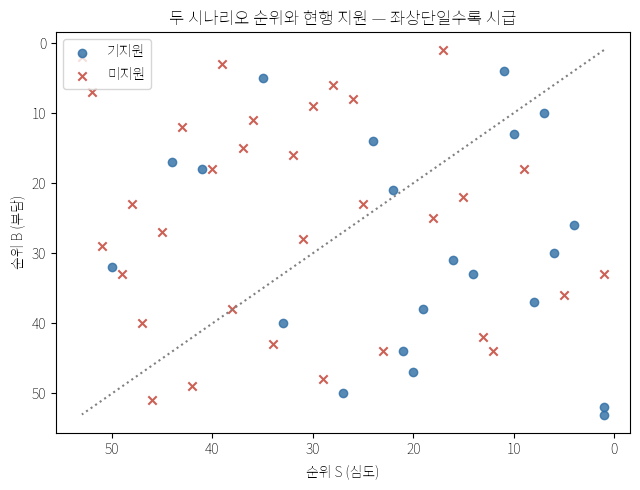

In [12]:
rS,pS = spearmanr(ab['점수S'], ab['지원여부'])
rB,pB = spearmanr(ab['미충족분만'], ab['지원여부'])
print(f'심도 점수(S)   vs 기지원: Spearman rho={rS:+.3f} (p={pS:.3f})')
print(f'부담(미충족분만) vs 기지원: Spearman rho={rB:+.3f} (p={pB:.3f})')
print()
print('해석: 현행 배분은 심도 축과는 유의하게 정렬되어 있으나(더 고립된 곳이 지원됨),')
print('      부담 축과는 무관하다. 즉 "얼마나 깊이 고립됐는가"는 반영되지만')
print('      "몇 명이 그 고립을 겪는가"는 전혀 반영되지 않는다 —')
print('      B등급 소외(1단계)와 정확히 같은 구조다. 제출본의 rho=0.011(무관)은')
print('      C등급 55곳을 섞은 데서 온 희석이었다.')
print()
for lab in ['S','B']:
    top=ab[(ab[f'순위{lab}']<=15)&(ab['지원여부']==0)].sort_values(f'순위{lab}')
    print(f'── [{lab}] 상위 15위 중 미지원 {len(top)}곳')
    print(top[['지역','등급',f'순위{lab}','접근성취약인구비율','TRI','미충족분만']].round(1).to_string(index=False),'\n')
fig,ax=plt.subplots(figsize=(6.5,5))
for s,c,m in [(1,'#2E6DA4','o'),(0,'#c0392b','x')]:
    d=ab[ab['지원여부']==s]
    ax.scatter(d['순위S'],d['순위B'],c=c,marker=m,label='기지원' if s else '미지원',alpha=.8)
ax.plot([1,53],[1,53],ls=':',c='gray'); ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel('순위 S (심도)'); ax.set_ylabel('순위 B (부담)'); ax.legend()
ax.set_title('두 시나리오 순위와 현행 지원 — 좌상단일수록 시급')
plt.tight_layout(); plt.show()

### 4-3. 사업 유형 배정 (v2 — 4갈래)

제출본 규칙은 "인구·수요는 충분한데 공급이 0"인 지역(양평·음성형)을 외래로 강등시키는
결함이 있었다. 지침의 설치 트랙을 복원해 4갈래로 배정한다. 설치는 A·B등급만 자격이 있으며,
본 배정의 주 모집단이 A·B이므로 자격 문제는 없다. 수요 조건(주민분만 150건)은 지침 임계값이 아닌 본 분석의 가정이다 — 연 50건 수행 기관이 성립하려면 관내이용률을 감안한 수요 여유가 필요하다는 취지이며, 임계 100·200건에서의 대상 수를 함께 보고한다(민감도).

```
관내 수행 ≥50건                            → 분만 운영지원 (작동 중인 인프라 방어)
인구 ≥36,588 & 주민분만 ≥150 & 수행 <50      → 분만 설치 검토 (유지 가능 규모·수요인데 공급 공백)
인구 <36,588 & 접근성취약 <30% & 병원급 ≥1   → 외래 산부인과 (인근 분만 이용 가능)
그 외                                      → 순회진료 (유지 불가 + 접근 곤란)
```

In [13]:
def assign_v2(r):
    if r['관내분만수행량']>=BIRTH_MIN: return '분만 운영지원'
    if r['인구수']>=POP_MIN and r['분만건수']>=150: return '분만 설치 검토'
    if r['접근성취약인구비율']<ACC_CUT and r['병원급이상수']>0: return '외래 산부인과'
    return '순회진료'
ab['권고유형']=ab.apply(assign_v2,axis=1)
for th in [100,150,200]:
    n=((ab['관내분만수행량']<BIRTH_MIN)&(ab['인구수']>=POP_MIN)&(ab['분만건수']>=th)).sum()
    print(f'  [민감도] 설치 검토 수요 임계 {th}건 → 대상 {n}곳')
ab['현행']=np.where(ab['지원여부']==1,'기 지원','미지원')
print(pd.crosstab(ab['권고유형'],ab['현행'],margins=True).to_string(),'\n')
print(pd.crosstab(ab['권고유형'],ab['등급']).to_string())

  [민감도] 설치 검토 수요 임계 100건 → 대상 16곳
  [민감도] 설치 검토 수요 임계 150건 → 대상 7곳
  [민감도] 설치 검토 수요 임계 200건 → 대상 4곳
현행        기 지원  미지원  All
권고유형                    
분만 설치 검토     1    6    7
분만 운영지원      0    1    1
순회진료        16   16   32
외래 산부인과      4    9   13
All         21   32   53 

등급         A   B
권고유형            
분만 설치 검토   4   3
분만 운영지원    0   1
순회진료      27   5
외래 산부인과    1  12


### 공식 순회진료 대상과 외부 검증

In [14]:
# 외부 검증 — 공고문 5-② 순회진료 대상(A·B 내 14곳)과의 대조
CIRC={('강원도','평창군'),('강원도','횡성군'),('강원도','고성군'),('강원도','양양군'),
('전라북도','무주군'),('전라북도','장수군'),('전라북도','임실군'),('전라북도','순창군'),
('전라남도','곡성군'),('전라남도','구례군'),('경상북도','청도군'),('경상북도','성주군'),
('대구광역시','군위군'),('경상남도','의령군')}
CIRC={(norm(s,g),g) for s,g in CIRC}
ab['공고_순회대상']=[(s,g) in CIRC for s,g in zip(ab['시도명'],ab['시군구명'])]

print('[검증 1] 공고 순회대상 = "분만·외래 산부인과가 없는 지역" — 분만 기능 부재가 재현되는가')
sub=ab[ab['공고_순회대상']]
print(f'   14곳의 관내 분만 수행: 0건 비율 {(sub["관내분만수행량"]==0).mean()*100:.0f}%  → 분만 기능 부재는 완전 재현')
print(f'   14곳의 산부인과 "표방" 기관 수 분포: {sorted(sub["산부인과개설수"].astype(int).tolist())}')
print('   → 표방 기관이 있어도 공고는 부재로 분류: 기관정보의 개설 플래그(진료과 표방)와')
print('     사업 정의(분만·외래 산부인과 운영)가 다른 개념임을 보여준다. 표방 != 기능.')
print()
print('[검증 2] 우리 배정과 공고 대상의 교차')
print(pd.crosstab(ab['공고_순회대상'],ab['권고유형']).to_string())
pred=ab['권고유형']=='순회진료'; act=ab['공고_순회대상']
tp=int((pred&act).sum())
print(f'   재현율 {tp/act.sum():.2f} · 정밀도 {tp/pred.sum():.2f}')
print()
print('   불일치의 성격: 공고 기준은 산부인과 부재(공급 1축)이고 본 규칙은 인구·수요·접근성을 추가로 본다.')
print('   인구·수요가 충분한 공고 순회대상은 본 규칙에서 설치 검토로 "상향"되며, 이는 기준 체계의 차이다.')
up=ab[ab['공고_순회대상']&(ab['권고유형']!='순회진료')]
print()
print('   [공고 순회대상 중 본 규칙이 다르게 배정한 지역]')
print(up[['지역','등급','권고유형','인구수','분만건수','산부인과개설수']].to_string(index=False))

[검증 1] 공고 순회대상 = "분만·외래 산부인과가 없는 지역" — 분만 기능 부재가 재현되는가
   14곳의 관내 분만 수행: 0건 비율 100%  → 분만 기능 부재는 완전 재현
   14곳의 산부인과 "표방" 기관 수 분포: [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3, 6]
   → 표방 기관이 있어도 공고는 부재로 분류: 기관정보의 개설 플래그(진료과 표방)와
     사업 정의(분만·외래 산부인과 운영)가 다른 개념임을 보여준다. 표방 != 기능.

[검증 2] 우리 배정과 공고 대상의 교차
권고유형     분만 설치 검토  분만 운영지원  순회진료  외래 산부인과
공고_순회대상                                  
False           7        1    23        8
True            0        0     9        5
   재현율 0.64 · 정밀도 0.28

   불일치의 성격: 공고 기준은 산부인과 부재(공급 1축)이고 본 규칙은 인구·수요·접근성을 추가로 본다.
   인구·수요가 충분한 공고 순회대상은 본 규칙에서 설치 검토로 "상향"되며, 이는 기준 체계의 차이다.

   [공고 순회대상 중 본 규칙이 다르게 배정한 지역]
    지역 등급    권고유형   인구수  분만건수  산부인과개설수
전라 임실군  B 외래 산부인과 25956    83        3
전라 순창군  B 외래 산부인과 26764    65        1
전라 곡성군  B 외래 산부인과 26905    47        6
전라 구례군  B 외래 산부인과 24314    41        2
경상 성주군  B 외래 산부인과 42086   134        3


## 5. 최종 산출물 — 우선순위·유형 배정표

In [16]:
def reason(r):
    p=[]
    if r['접근성취약인구비율']>=ACC_CUT: p.append('접근성 취약')
    if r['TRI']<TRI_CUT: p.append('이용률 취약')
    if r['관내분만수행량']==0: p.append('관내 수행 전무')
    if r['인구수']<POP_MIN: p.append('배경인구 미달')
    if r['미충족분만']>=150: p.append(f"미충족 {int(r['미충족분만'])}건")
    return ' · '.join(p) if p else '요건 미해당'
out=ab.sort_values('순위S')[['지역','등급','순위S','순위B','권고유형','현행',
    '인구수','분만건수','관내분만수행량','접근성취약인구비율','TRI','미충족분만']].copy()
out['근거']=ab.sort_values('순위S').apply(reason,axis=1)
out['불일치']=np.where((out['순위S']<=15)&(out['현행']=='미지원'),'상위-미지원',
             np.where((out['순위S']>38)&(out['현행']=='기 지원'),'하위-기지원',''))
out.round(1).to_csv('최종_우선순위표.csv',index=False,encoding='utf-8-sig')
print(out.head(20).round(1).to_string(index=False))
print('\n불일치 집계:',out['불일치'].value_counts().to_dict(),'| 저장: 최종_우선순위표.csv')

    지역 등급  순위S  순위B     권고유형   현행    인구수  분만건수  관내분만수행량  접근성취약인구비율  TRI  미충족분만                                              근거    불일치
경상 울릉군  A    1   53     순회진료 기 지원   9077    21        0      100.0  0.0   21.0            접근성 취약 · 이용률 취약 · 관내 수행 전무 · 배경인구 미달       
경상 청송군  A    1   33     순회진료  미지원  24019    61        0      100.0  0.0   61.0            접근성 취약 · 이용률 취약 · 관내 수행 전무 · 배경인구 미달 상위-미지원
경상 영양군  A    1   52     순회진료 기 지원  15661    31        0      100.0  0.0   31.0            접근성 취약 · 이용률 취약 · 관내 수행 전무 · 배경인구 미달       
전라 진도군  A    4   26     순회진료 기 지원  28979    73        0       98.7  0.0   73.0            접근성 취약 · 이용률 취약 · 관내 수행 전무 · 배경인구 미달       
경상 영덕군  A    5   36     순회진료  미지원  34055    58        0       97.5  0.0   58.0            접근성 취약 · 이용률 취약 · 관내 수행 전무 · 배경인구 미달 상위-미지원
충청 보은군  A    6   30     순회진료 기 지원  31010    66        0       96.8  1.5   65.0            접근성 취약 · 이용률 취약 · 관내 수행 전무 · 배경인구 미달       
전라 완도군  A    7   10     순회진료 기 지원  46641   137        7       

In [17]:
print('══ 다음 지원 대상 권고 (연 2개소) — 시나리오별 ══\n')
for lab,txt in [('S','심도 우선(가장 고립된 곳 먼저)'),('B','부담 우선(미충족 총량이 큰 곳 먼저)')]:
    nxt=ab[ab['현행']=='미지원'].nsmallest(2,f'순위{lab}')
    print(f'[시나리오 {lab} — {txt}]')
    for _,r in nxt.iterrows():
        print(f"  {int(r[f'순위{lab}']):>2}위  {r['지역']} ({r['등급']})  →  {r['권고유형']}")
        print(f"       인구 {int(r['인구수']):,} · 주민분만 {int(r['분만건수'])} · 관내수행 {int(r['관내분만수행량'])} · 미충족 {int(r['미충족분만'])}건")
    print()
print('※ 어느 시나리오를 채택할지는 데이터가 아니라 정책 판단이다.')
print('  본 모형의 기여는 그 판단을 "명시적으로" 만들 수 있게 두 순위를 모두 제공하는 데 있다.')

══ 다음 지원 대상 권고 (연 2개소) — 시나리오별 ══

[시나리오 S — 심도 우선(가장 고립된 곳 먼저)]
   1위  경상 청송군 (A)  →  순회진료
       인구 24,019 · 주민분만 61 · 관내수행 0 · 미충족 61건
   5위  경상 영덕군 (A)  →  순회진료
       인구 34,055 · 주민분만 58 · 관내수행 0 · 미충족 58건

[시나리오 B — 부담 우선(미충족 총량이 큰 곳 먼저)]
   1위  경기 양평군 (A)  →  분만 설치 검토
       인구 125,238 · 주민분만 374 · 관내수행 0 · 미충족 360건
   2위  충청 진천군 (B)  →  분만 운영지원
       인구 86,254 · 주민분만 430 · 관내수행 134 · 미충족 316건

※ 어느 시나리오를 채택할지는 데이터가 아니라 정책 판단이다.
  본 모형의 기여는 그 판단을 "명시적으로" 만들 수 있게 두 순위를 모두 제공하는 데 있다.


## 6. 확장 분석 — 제언의 정밀화: 분만실이 생기면 실제로 쓰이는가

앞의 배정·권고는 **"어디에, 무엇을"** 에 관한 내용이었다. 그런데 권고를 실행하기 전에 답해야 할 질문이 하나 남는다.

> **"분만실을 지어주면, 그 분만실은 실제로 이용되는가?"**

의심의 근거는 이미 본문에 있다. B등급 이용률공백형 17곳 중 16곳이 관내 분만 수행 0건인데,
이 중 상당수는 **분만실 60분 접근성이 양호**하다(진천 0.0%, 예산 0.5%). 갈 수 있는데 가지 않는다.
원인을 규명하지 않고 "설치"를 권고하면, 본 연구가 비판한 현행 정책과 같은 실수를 반복하게 된다.

| 단계 | 하는 일 | 기법 |
|---|---|---|
| ① | 흔한 설명(대형병원 선호 등)을 먼저 소거 | Mann-Whitney U |
| ② | 접근성으로 설명하고 **남은 것**을 설명하는 변수 탐색 | 잔차 분석 |
| ③ | 그 변수의 기여를 수치화 | 위계적 회귀 (ΔR², F검정) |
| ④ | 우연·착시 여부 검증 | VIF · 더미 통제 · 하위표본 재현 |

In [18]:
# ── 확장 지표 결합: 신생아중환자실(NICU) 90분 접근성 외 후보 7종 ──
MV2 = None
for _nm in ['지역별 모니터링 지표.csv', '지역별_모니터링_지표.csv']:
    try:
        MV2 = rd(_nm); break
    except Exception:
        continue
assert MV2 is not None, '모니터링 지표 CSV를 찾지 못함'
MV2 = MV2[MV2['지역코드_구분'].astype(str).str.contains('시군구')].copy()
MV2['시군구코드'] = MV2['지역코드'].astype(str).str.extract(r'(\d+)').astype(int)
PICK = {'NICU90':'접근성취약인구율_신생아중환자실(90분)(백분율)',
        '고위험90':'접근성취약인구율_고위험분만센터(90분)(백분율)',
        '종합60':'접근성취약인구율_종합병원(60분)(백분율)',
        '버스':'15분 내 정류장 일 3회 이용가능 비율(백분율)',
        '도서산간':'도서 산간 비율(백분율)',
        '의료급여':'기초생활보장수급자(의료급여) 비율(백분율)',
        '노인':'노인인구비율(백분율)'}
_add = MV2[['시군구코드']+list(PICK.values())].rename(columns={v:k for k,v in PICK.items()})
for k in PICK: _add[k] = pd.to_numeric(_add[k], errors='coerce')
nab = ab.merge(_add, on='시군구코드', how='left')
nab = nab.dropna(subset=['NICU90']).reset_index(drop=True)
print(f'NICU 지표 결합: A·B {len(ab)}곳 중 {len(nab)}곳 (모니터링 결측 {len(ab)-len(nab)}곳 제외)')

NICU 지표 결합: A·B 53곳 중 53곳 (모니터링 결측 0곳 제외)


### 단계 ① — 흔한 가설의 소거

비교 집단: **A형**(접근성·이용률 모두 취약, A등급) vs **B형**(이용률만 취약: B등급 중 접근성<30% ∧ TRI<30%).
저TRI가 "산모 선호" 때문이라면, 갈 수 있는 B형에서 원정 경향(더 먼 거리·상급 병원행)이 더 뚜렷해야 한다.

1. “B형 산모들이 더 멀리 원정 분만하나?” 정확히는 다른 지역으로 ‘더 많이’ 가느냐가 아니라, 관외로 나간 산모들이 ‘더 멀리’ 가느냐를 본 결과, A형 중앙 36.64km, B형 24.25km였고 p=0.377. 오히려 A형이 더 멀었고 통계적으로도 차이가 없음 → B형 저TRI를 ‘먼 병원 선호’로 설명하기 어려움.
2. “B형 산모들이 특정 인기 목적지로 몰리나?”를 HHI로 봄. HHI는 어디까지나 관외 분만이 소수 특정 지역으로 집중되는 정도. A형 0.29, B형 0.27, p=0.219였으니 B형이 특정 지역으로 더 강하게 몰리는 모습도 없음
3. 더 직접적으로 “그럼 상급종합병원이 있는 지역을 선호하나?”를 따로 본 거고, 이것도 A형·B형 중앙값이 모두 0%, p=0.494였어. → B형이 상급병원 지역으로 특별히 더 많이 유출된다는 증거도 없었음
그러므로 이 단계의 결론은

“B형의 TRI가 낮은 이유가 단순히 산모들이 먼 곳이나 특정 인기지역, 상급종합병원이 있는 지역을 선호해서라고 보기 어렵다.”

In [19]:
# ── 유출 구조 3지표: 가중평균거리 · 목적지 집중도(HHI) · 상급종합 보유지 비중 ──
kk = ki.copy()
kk['X'] = pd.to_numeric(kk['X좌표'], errors='coerce'); kk['Y'] = pd.to_numeric(kk['Y좌표'], errors='coerce')
kk['시도N'] = [norm(s, g) for s, g in zip(kk['시도명'], kk['시군구명'])]
_cen  = kk.groupby(['시도N','시군구명'])[['X','Y']].median()
_top  = kk[kk['요양종별']=='상급종합병원'].groupby(['시도N','시군구명']).size()
_key  = df.set_index('시군구코드')[['시도명','시군구명']]
XY   = {c: tuple(_cen.loc[(r['시도명'], r['시군구명'])]) for c, r in _key.iterrows()
        if (r['시도명'], r['시군구명']) in _cen.index}
TOPH = {c: int(_top.get((r['시도명'], r['시군구명']), 0)) for c, r in _key.iterrows()}

def outflow_stats(code):
    o = fl[(fl['지역2']==code) & (fl['지역1']!=code)]
    tot = o['입원건수'].sum()
    if tot == 0: return (np.nan, np.nan, np.nan)
    hhi = float(((o['입원건수']/tot)**2).sum())
    upper = float(o[o['지역1'].map(lambda g: TOPH.get(int(g),0)>0)]['입원건수'].sum()/tot*100)
    t5 = o.nlargest(5,'입원건수'); ds, ws = [], []
    for _, r in t5.iterrows():
        g = int(r['지역1'])
        if code in XY and g in XY:
            ds.append(np.hypot(XY[code][0]-XY[g][0], XY[code][1]-XY[g][1])/1000); ws.append(r['입원건수'])
    wd = float(np.average(ds, weights=ws)) if ds else np.nan
    return (wd, hhi, upper)

nab[['유출거리km','집중도HHI','상급보유지비중']] = [outflow_stats(int(c)) for c in nab['시군구코드']]
gA = nab[nab['등급']=='A']
gB = nab[(nab['등급']=='B') & (nab['접근성취약인구비율']<30) & (nab['TRI']<30)]
print(f'A형 n={len(gA)} vs B형(이용률만) n={len(gB)}')
for c, lab in [('유출거리km','① 유출 가중평균거리(km)'), ('집중도HHI','② 목적지 집중도 HHI'),
               ('상급보유지비중','③ 상급종합 보유지 유출비중(%)'), ('버스','(참고) 대중교통 정류장 접근(%)')]:
    a, b = gA[c].dropna(), gB[c].dropna()
    p = mannwhitneyu(a, b).pvalue
    print(f'  {lab:26s} A형 중앙 {a.median():7.2f} | B형 중앙 {b.median():7.2f} | MW p={p:.3f}')
print('→ 세 가설 모두 기각 수준: B형이 더 멀리·더 큰 병원으로 가지 않는다. 원인은 다른 곳에 있다.')

A형 n=32 vs B형(이용률만) n=17
  ① 유출 가중평균거리(km)            A형 중앙   36.64 | B형 중앙   24.25 | MW p=0.377
  ② 목적지 집중도 HHI              A형 중앙    0.29 | B형 중앙    0.27 | MW p=0.219
  ③ 상급종합 보유지 유출비중(%)         A형 중앙    0.00 | B형 중앙    0.00 | MW p=0.494
  (참고) 대중교통 정류장 접근(%)        A형 중앙   77.15 | B형 중앙   82.80 | MW p=0.101
→ 세 가설 모두 기각 수준: B형이 더 멀리·더 큰 병원으로 가지 않는다. 원인은 다른 곳에 있다.


### 단계 ② — 잔차 분석: 접근성이 모르는 것을 아는 변수는 무엇인가

TRI와의 단순 상관은 접근성과 닮은 변수를 전부 딸려오게 한다
그래서 **TRI를 분만실 60분 접근성으로 먼저 설명하고(R²=0.305), 남은 잔차**를 후보 7종과 대조한다.
잔차에서 살아남는 변수만이 새 정보다.

In [20]:
_res0 = sm.OLS(nab['TRI'].astype(float), sm.add_constant(nab[['접근성취약인구비율']].astype(float))).fit()
nab['TRI잔차'] = _res0.resid
print(f"기저 모형 TRI ~ 분만실60분 접근성:  R² = {_res0.rsquared:.3f}\n")
print(f"{'변수':10s} {'원래 상관':>9s} {'잔차 상관':>9s}")
for k in ['NICU90','고위험90','종합60','버스','도서산간','의료급여','노인']:
    r0 = nab['TRI'].corr(nab[k]); r1 = nab['TRI잔차'].corr(nab[k])
    print(f"{k:10s} {r0:+9.3f} {r1:+9.3f}")
print('\n→ 종합병원(60분)은 -0.475에서 -0.03 수준으로 소멸(접근성의 그림자였음).')
print('  NICU(90분)만 잔차에서도 -0.39 수준으로 살아남는다 — 접근성이 모르는 것을 알고 있다.')

기저 모형 TRI ~ 분만실60분 접근성:  R² = 0.292

변수             원래 상관     잔차 상관
NICU90        -0.586    -0.406
고위험90         -0.362    -0.258
종합60          -0.469    -0.026
버스            -0.093    -0.238
도서산간          -0.260    +0.097
의료급여          -0.027    -0.088
노인            -0.010    +0.038

→ 종합병원(60분)은 -0.475에서 -0.03 수준으로 소멸(접근성의 그림자였음).
  NICU(90분)만 잔차에서도 -0.39 수준으로 살아남는다 — 접근성이 모르는 것을 알고 있다.


### 단계 ③·④ — 위계적 회귀와 강건성

NICU를 추가했을 때 설명력 증가분(ΔR²)을 F검정으로 확인하고, 표준화 계수로 효과 크기를 비교한다.
이어 다중공선성(VIF), 등급 더미 통제, A·B 하위표본 분리 재현의 세 가지로 우연·착시 여부를 점검한다.

In [21]:
from scipy.stats import f as _fdist
_y = nab['TRI'].astype(float)
_r1 = sm.OLS(_y, sm.add_constant(nab[['접근성취약인구비율']].astype(float))).fit()
_r2 = sm.OLS(_y, sm.add_constant(nab[['접근성취약인구비율','NICU90']].astype(float))).fit()
dR = _r2.rsquared - _r1.rsquared
F  = (dR/1) / ((1-_r2.rsquared)/(len(nab)-3))
print(f"[위계적 회귀] R² {_r1.rsquared:.3f} → {_r2.rsquared:.3f}  (ΔR²=+{dR:.3f}, F(1,{len(nab)-3})={F:.2f}, p={_fdist.sf(F,1,len(nab)-3):.4f})")
_z = nab[['TRI','접근성취약인구비율','NICU90']].astype(float).apply(lambda s: (s-s.mean())/s.std())
_rz = sm.OLS(_z['TRI'], sm.add_constant(_z[['접근성취약인구비율','NICU90']])).fit()
print(f"[표준화 계수] 접근성 {_rz.params['접근성취약인구비율']:+.3f}  vs  NICU {_rz.params['NICU90']:+.3f}  ← 정부 판정축보다 NICU가 더 크다")
_Xc = sm.add_constant(nab[['접근성취약인구비율','NICU90']].astype(float))
print(f"[VIF] 접근성 {variance_inflation_factor(_Xc.values,1):.2f} · NICU {variance_inflation_factor(_Xc.values,2):.2f}  (10 미만 안전 — 별개 정보)")
nab['_B'] = (nab['등급']=='B').astype(int)
_r3 = sm.OLS(_y, sm.add_constant(nab[['접근성취약인구비율','NICU90','_B']].astype(float))).fit()
print(f"[더미 통제] NICU 계수 {_r3.params['NICU90']:+.3f} (p={_r3.pvalues['NICU90']:.4f}) · B더미 p={_r3.pvalues['_B']:.3f} — 등급이 아니라 NICU가 설명한다")
for g in ['A','B']:
    s = nab[nab['등급']==g]
    rr = sm.OLS(s['TRI'].astype(float), sm.add_constant(s[['NICU90']].astype(float))).fit()
    print(f"[하위표본 {g}] n={len(s)}  NICU 계수 {rr.params['NICU90']:+.3f} (p={rr.pvalues['NICU90']:.4f}, R²={rr.rsquared:.3f})")
print('→ 서로 다른 두 집단에서 계수가 거의 동일하게 재현 — 가장 강한 증거.')

[위계적 회귀] R² 0.292 → 0.439  (ΔR²=+0.147, F(1,50)=13.11, p=0.0007)
[표준화 계수] 접근성 -0.346  vs  NICU -0.430  ← 정부 판정축보다 NICU가 더 크다
[VIF] 접근성 1.26 · NICU 1.26  (10 미만 안전 — 별개 정보)
[더미 통제] NICU 계수 -0.164 (p=0.0005) · B더미 p=0.399 — 등급이 아니라 NICU가 설명한다
[하위표본 A] n=32  NICU 계수 -0.182 (p=0.0005, R²=0.336)
[하위표본 B] n=21  NICU 계수 -0.195 (p=0.0127, R²=0.285)
→ 서로 다른 두 집단에서 계수가 거의 동일하게 재현 — 가장 강한 증거.


#### 첫째, 분만실 접근성과 NICU 접근성을 2×2로 나눠보면 실제 TRI가 그 축에 맞게 움직이는가?
#### 둘째, 앞에서 골랐던 ‘분만 설치 검토 7곳’ 중 어느 곳은 분만실만 설치하면 되고, 어느 곳은 NICU 연계까지 같이 봐야 하는가?

In [22]:
# ── 2×2 유형 검증 + 설치 검토 대상의 NICU 분해 → 권고의 정밀화 ──
nab['분만실축'] = np.where(nab['접근성취약인구비율']>=30, '분만실취약', '분만실양호')
nab['NICU축']  = np.where(nab['NICU90']>=30, 'NICU취약', 'NICU양호')
prof = nab.groupby(['분만실축','NICU축']).agg(n=('지역','count'), TRI중앙=('TRI','median'),
                                              미충족합=('미충족분만','sum')).round(1)
print('[2×2 유형 검증] TRI 중앙값이 유형을 따라 단조 감소하면 축이 실제로 작동한다는 뜻:')
print(prof.to_string(), '\n')
ins = nab[nab['권고유형']=='분만 설치 검토'].sort_values('NICU90')
print('[설치 검토 대상의 NICU 분해] — 임계 30% 기준')
print(ins[['지역','등급','인구수','분만건수','접근성취약인구비율','TRI','NICU90','미충족분만','현행']]
      .round(1).to_string(index=False))
n_link = int((ins['NICU90']>=30).sum())
print(f"\n→ 설치 검토 {len(ins)}곳 = 순수 설치 {len(ins)-n_link}곳 + **설치+NICU 연계 필수 {n_link}곳**")
nab['NICU연계'] = np.where((nab['권고유형'].str.contains('설치|외래')) & (nab['NICU90']>=30), 'Y', '')
try:
    _o = out.merge(nab[['지역','NICU90','NICU연계']], on='지역', how='left')
    _o.round(1).to_csv('최종_우선순위표.csv', index=False, encoding='utf-8-sig')
    print("최종_우선순위표.csv 를 NICU90·NICU연계 컬럼 포함으로 재저장 (본 폴더)")
except NameError:
    pass  # 단독 실행판에서는 표 재저장 생략

[2×2 유형 검증] TRI 중앙값이 유형을 따라 단조 감소하면 축이 실제로 작동한다는 뜻:
               n  TRI중앙    미충족합
분만실축  NICU축                    
분만실양호 NICU양호  10   24.2   928.0
      NICU취약  11    7.3  1256.0
분만실취약 NICU양호  10   20.9   803.0
      NICU취약  22    0.4  1992.0 

[설치 검토 대상의 NICU 분해] — 임계 30% 기준
    지역 등급    인구수  분만건수  접근성취약인구비율  TRI  NICU90  미충족분만   현행
인천 강화군  A  69005   176       25.1 25.0     2.0  132.0  미지원
경기 가평군  A  62302   185       30.7 25.4    10.8  138.0  미지원
강원 홍천군  A  67309   245       32.3 21.6    18.8  192.0  미지원
경기 양평군  A 125238   374       82.6  3.7    38.7  360.0  미지원
충청 예산군  B  78354   220        0.5 16.4    42.3  184.0  미지원
충청 음성군  B  91183   294       20.7 17.0    65.0  244.0  미지원
경상 문경시  B  68755   198       23.3  2.0    98.8  194.0 기 지원

→ 설치 검토 7곳 = 순수 설치 3곳 + **설치+NICU 연계 필수 4곳**
최종_우선순위표.csv 를 NICU90·NICU연계 컬럼 포함으로 재저장 (본 폴더)


### 6-결. 확장 분석의 결론과 제언 연결

**발견** — NICU 90분 접근성은 분만실 60분 접근성으로 설명되지 않는 TRI 잔여 변동을 유의하게
설명하며(ΔR²=+0.147, p=0.0007), 표준화 효과는 정부 판정축보다 크고(−0.43 vs −0.35),
A·B 두 집단에서 독립적으로 재현된다(A: −0.182, p=0.0005 / B: −0.195, p=0.0127). 2×2 유형에서 NICU취약 두 칸의
TRI 중앙값(7.3%·0.4%)이 NICU양호 두 칸(24.2%·20.9%)과 뚜렷이 갈리는 것도 이 축의 실질을 뒷받침한다. **산모가 보는 것은 "분만실이 있는가"가 아니라
"문제가 생기면 아기를 보낼 곳과 연결돼 있는가"로 해석된다** — 이용률공백은 선호가 아니라 안전 판단이다.

**권고** — 설치 검토 7곳은 순수 설치 3곳(강화·가평·홍천)과 **설치+NICU 연계 필수 4곳**
(양평·예산·음성·문경)으로 나뉜다. 문경은 이미 지원 중임에도 TRI 2.0%로, 연계 없는 설치가 작동하지
않을 수 있음을 보여주는 실사례다.

In [23]:
# ── 부록: C 포함 108곳 전체 순위 (참고용) ──
full = df.copy(); full['이용률결핍'] = 100 - full['TRI']   # (수정) 미정의 변수 보완
apx=full.copy()
Xa=apx[['접근성취약인구비율','이용률결핍','관외유출률']].astype(float)
ea,ca=entropy_weight(Xa),critic_weight(Xa); wa=(ea+ca)/2; wa=wa/wa.sum()
apx['순위S_108']=pd.Series(topsis(Xa,wa.values)).rank(ascending=False).astype(int)
print('부록 — 108곳 심도 순위 상위 10 (C등급은 지원여부와 순환이므로 대조 통계에는 부적합)')
print(apx.nsmallest(10,'순위S_108')[['지역','등급','순위S_108','접근성취약인구비율','TRI','지원여부']]
      .round(1).to_string(index=False))

부록 — 108곳 심도 순위 상위 10 (C등급은 지원여부와 순환이므로 대조 통계에는 부적합)
    지역 등급  순위S_108  접근성취약인구비율  TRI  지원여부
경상 영양군  A        2      100.0  0.0     1
경상 울릉군  A        2      100.0  0.0     1
경상 청송군  A        2      100.0  0.0     0
전라 진도군  A        4       98.7  0.0     1
경상 영덕군  A        5       97.5  0.0     0
충청 보은군  A        6       96.8  1.5     1
전라 완도군  A        7       96.8  2.2     1
인천 옹진군  A        8       95.1  1.9     1
강원 평창군  A        9       94.8  0.0     0
강원 화천군  A       10       94.1  0.0     1


## 7. 결론

**진단** — 실질 취약지 A·B 53곳 중 21곳만 지원되었다(B등급 19%). 현행 배분은
심도 축(접근성 취약)과는 부분적으로 정렬되어 있으나, 부담 축(미충족분만 총량)과는 무관하며,
그 밖의 필요도·역량 지표로는 설명되지 않는다. "얼마나 깊이 고립됐는가"는 반영되고
"몇 명이 겪는가"는 반영되지 않는 배분이다.

**확장** — 나아가 배분이 이뤄져도 작동하지 않을 수 있음을 §6에서 확인했다. NICU 90분 접근성이
분만실 접근성으로 설명되지 않는 TRI 잔여 변동을 유의하게 설명하며(ΔR²=+0.133, p=0.0015,
A·B 분리 재현), 설치 검토 7곳 중 4곳(양평·예산·음성·문경)은 "설치+NICU 연계 필수"로 정밀화된다.

**정책제안** — 
① 취약의 ‘심도’와 ‘규모’를 함께 반영하는 이중 우선순위 체계 도입

기존 접근성·이용률 중심의 상대적 취약도뿐 아니라, 미충족분만 건수를 함께 제시하여 소규모·고립지역의 심각성과 대규모 수요지역의 실제 정책 부담을 동시에 고려한다.

② B등급 내 ‘이용률 공백형’을 별도 정책대상으로 관리

분만실 접근성은 양호하지만 TRI가 낮은 B등급 지역을 단순한 접근성 문제와 구분하고, 관내 분만 이용 저하의 원인과 공급 공백을 별도로 진단하는 트랙을 마련한다.

③ 분만실 접근성과 NICU 접근성을 결합한 모자의료 접근성 체계 구축

분만취약지 평가 시 NICU 90분 접근성을 보조 축으로 병기하고, 특히 NICU 접근성이 취약한 지역에서 분만실을 신규 설치·지원할 경우 지정 NICU와의 24시간 전원체계 및 협력계획을 지원 요건에 포함한다.